In [11]:
!pip install numpy -q
!pip install torch torchvision -q
!pip install opencv-python -q
!pip install pillow -q
!pip install matplotlib -q
!pip install tqdm -q
!pip install scikit-image -q
!pip install python-docx -q
!pip install PyPDF2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 10.9 MB/s eta 0:00:00


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFont, ImageDraw
import cv2
import docx


In [16]:
def render_text(text, font_path="goudy_old_style.ttf", img_size=(512, 768)):
    try:
        img = Image.new('L', img_size, color=255)
        draw = ImageDraw.Draw(img)

        font_size = int(img_size[0] / 25)
        try:
            font = ImageFont.truetype(font_path, font_size)
        except OSError:
            print(f"Could not load font {font_path}. Using default.")
            font = ImageFont.load_default()

        margin = 20
        y_offset = margin
        max_width = img_size[0] - 2 * margin

        lines = []
        current_line = []
        words = text.split()

        for word in words:
            test_line = ' '.join(current_line + [word])
            bbox = draw.textbbox((0, 0), test_line, font=font)
            line_width = bbox[2] - bbox[0]

            if line_width <= max_width:
                current_line.append(word)
            else:
                lines.append(' '.join(current_line))
                current_line = [word]

        if current_line:
            lines.append(' '.join(current_line))

        for line in lines:
            draw.text((margin, y_offset), line, font=font, fill=0)
            bbox = draw.textbbox((margin, y_offset), line, font=font)
            line_height = bbox[3] - bbox[1]
            y_offset += line_height + 5

            if y_offset >= img_size[1] - margin:
                break

        return img

    except Exception as e:
        print(f"Error rendering text: {e}")
        return Image.new('L', img_size, color=255)



In [18]:

def apply_ink_bleed(image, intensity=0.5):
    img_array = np.array(image)

    kernel_size = max(1, int(3 * intensity))
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    dilated = cv2.dilate(img_array, kernel, iterations=1)

    result = cv2.addWeighted(img_array, 1 - intensity/2, dilated, intensity/2, 0)

    return Image.fromarray(result)






In [21]:
def apply_uneven_pressure(image, intensity=0.5):
    img_array = np.array(image)
    height, width = img_array.shape

    pressure = np.ones((height, width), dtype=np.float32)

    for _ in range(5):
        cx, cy = np.random.randint(0, width), np.random.randint(0, height)
        radius = np.random.randint(width//5, width//2)
        amount = np.random.uniform(-0.5, 0.5) * intensity

        y, x = np.ogrid[:height, :width]
        dist = np.sqrt((x - cx)**2 + (y - cy)**2)
        mask = dist <= radius

        falloff = (1 - dist[mask]/radius) * amount
        pressure[mask] = pressure[mask] * (1 + falloff)

    pressure = np.clip(pressure, 0.5, 1.5)

    result = img_array * pressure
    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)

In [22]:

def apply_paper_texture(image, intensity=0.5):
    img_array = np.array(image).astype(np.float32)

    texture = np.random.normal(200, 20, img_array.shape).astype(np.uint8)
    texture = cv2.GaussianBlur(texture, (51, 51), 10)

    texture = texture.astype(np.float32) / 255.0
    texture = np.clip((texture - 0.5) * 1.5 + 0.5, 0, 1)

    result = img_array * (1.0 - intensity * texture)
    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)











In [23]:

def apply_faded_ink(image, intensity=0.5):
    img_array = np.array(image).astype(np.float32)
    height, width = img_array.shape

    fade_map = np.zeros((height, width), dtype=np.float32)

    noise = np.random.normal(0, 1, (height, width))
    fade_noise = cv2.GaussianBlur(noise, (99, 99), 30)

    fade_noise = (fade_noise - fade_noise.min()) / (fade_noise.max() - fade_noise.min())

    fade_factor = intensity * fade_noise
    fade_factor = np.clip(fade_factor, 0, 0.7)

    result = img_array * (1 - fade_factor) + 255 * fade_factor
    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)

In [24]:
def apply_age_spots(image, num_spots=20, intensity=0.5):
    img_array = np.array(image).astype(np.float32)
    height, width = img_array.shape

    spots = np.zeros((height, width), dtype=np.float32)

    for _ in range(num_spots):
        cx, cy = np.random.randint(0, width), np.random.randint(0, height)
        radius = np.random.randint(5, 30)
        spot_intensity = np.random.uniform(0.2, 1.0) * intensity

        y, x = np.ogrid[:height, :width]
        dist = np.sqrt((x - cx)**2 + (y - cy)**2)
        mask = dist <= radius

        falloff = (1 - dist[mask]/radius) * spot_intensity
        spots[mask] = np.maximum(spots[mask], falloff)

    result = img_array * (1 - spots * 0.3)
    result = np.clip(result, 0, 255).astype(np.uint8)

    return Image.fromarray(result)

In [25]:

def apply_all_effects(image, intensity=0.5):
    img = apply_ink_bleed(image, intensity * np.random.uniform(0.3, 0.7))
    img = apply_uneven_pressure(img, intensity * np.random.uniform(0.4, 0.8))
    img = apply_faded_ink(img, intensity * np.random.uniform(0.3, 0.6))
    num_spots = int(20 * intensity * np.random.uniform(0.5, 1.5))
    img = apply_age_spots(img, num_spots, intensity * np.random.uniform(0.4, 0.7))
    img = apply_paper_texture(img, intensity * np.random.uniform(0.5, 0.9))

    return img

In [27]:
def compute_ssim(image1, image2):

    from skimage.metrics import structural_similarity as ssim

    if isinstance(image1, Image.Image):
        image1 = np.array(image1)
    if isinstance(image2, Image.Image):
        image2 = np.array(image2)

    if image1.shape != image2.shape:
        image2 = cv2.resize(image2, (image1.shape[1], image1.shape[0]))

    similarity = ssim(image1, image2)
    return similarity

In [28]:


def compute_psnr(image1, image2):
    from skimage.metrics import peak_signal_noise_ratio as psnr

    if isinstance(image1, Image.Image):
        image1 = np.array(image1)
    if isinstance(image2, Image.Image):
        image2 = np.array(image2)

    if image1.shape != image2.shape:
        image2 = cv2.resize(image2, (image1.shape[1], image1.shape[0]))

    return psnr(image1, image2)

In [29]:


def evaluate_degradation(clean_image, degraded_image):
    ssim_value = compute_ssim(clean_image, degraded_image)

    psnr_value = compute_psnr(clean_image, degraded_image)

    clean_array = np.array(clean_image)
    degraded_array = np.array(degraded_image)

    clean_edges = cv2.Canny(clean_array, 100, 200)
    degraded_edges = cv2.Canny(degraded_array, 100, 200)

    clean_edge_density = np.sum(clean_edges > 0) / (clean_array.shape[0] * clean_array.shape[1])
    degraded_edge_density = np.sum(degraded_edges > 0) / (degraded_array.shape[0] * degraded_array.shape[1])

    ink_bleed_score = degraded_edge_density / max(clean_edge_density, 0.001)

    return {
        'ssim': ssim_value,
        'psnr': psnr_value,
        'ink_bleed_score': ink_bleed_score
    }


In [30]:
def save_to_word(clean_images, degraded_images, output_path="renaissance_text_samples.docx"):
    doc = docx.Document()
    doc.add_heading('Renaissance-Style Text Generation Samples', 0)

    for i, (clean, degraded) in enumerate(zip(clean_images, degraded_images)):
        doc.add_heading(f'Sample {i+1}', level=1)

        clean_path = f"temp_clean_{i}.png"
        degraded_path = f"temp_degraded_{i}.png"

        clean.save(clean_path)
        degraded.save(degraded_path)

        doc.add_heading('Original Clean Text', level=2)
        doc.add_picture(clean_path, width=docx.shared.Inches(6))

        doc.add_heading('Renaissance-Style Degraded Text', level=2)
        doc.add_picture(degraded_path, width=docx.shared.Inches(6))

        metrics = evaluate_degradation(clean, degraded)
        doc.add_heading('Evaluation Metrics', level=2)

        metrics_text = f"""
        SSIM: {metrics['ssim']:.4f} (lower indicates more degradation)
        PSNR: {metrics['psnr']:.4f} dB (lower indicates more degradation)
        Ink Bleed Score: {metrics['ink_bleed_score']:.4f} (higher indicates more ink bleeding)
        """

        doc.add_paragraph(metrics_text)
        doc.add_page_break()

    doc.save(output_path)
    print(f"Word document saved to {output_path}")

    for i in range(len(clean_images)):
        os.remove(f"temp_clean_{i}.png")
        os.remove(f"temp_degraded_{i}.png")

In [31]:

def process_pdf_text(pdf_path):
    import PyPDF2
    import re

    text_samples = []
    try:
        with open(pdf_path, 'rb') as file:
            reader = PyPDF2.PdfReader(file)
            for page in reader.pages:
                page_text = page.extract_text()
                if page_text:
                    paragraphs = re.split(r'\n\s*\n', page_text)
                    for para in paragraphs:
                        if len(para.strip()) > 100:
                            text_samples.append(para.strip())
    except Exception as e:
        print(f"Error extracting text from PDF: {e}")

    return text_samples



In [32]:

def main(pdf_path='/content/Constituciones sinodales Calahorra 1602.pdf', font_path="goudy_old_style.ttf", output_dir="output", num_samples=5, effect_intensity=0.6):
    os.makedirs(output_dir, exist_ok=True)

    text_samples = []
    if pdf_path:
        text_samples = process_pdf_text(pdf_path)
        print(f"Extracted {len(text_samples)} text samples from PDF")

    if not text_samples:
        text_samples = ["This is placeholder text for testing the Renaissance text generation system."]

    clean_images = []
    degraded_images = []

    for i, text in enumerate(text_samples[:num_samples]):
        print(f"Processing sample {i+1}/{min(num_samples, len(text_samples))}...")

        clean_img = render_text(text, font_path)
        clean_images.append(clean_img)
        clean_img.save(f"{output_dir}/clean_sample_{i+1}.png")

        degraded_img = apply_all_effects(clean_img, intensity=effect_intensity)
        degraded_images.append(degraded_img)
        degraded_img.save(f"{output_dir}/degraded_sample_{i+1}.png")

        metrics = evaluate_degradation(clean_img, degraded_img)
        print(f"Sample {i+1} Metrics:")
        print(f"  SSIM: {metrics['ssim']:.4f}")
        print(f"  PSNR: {metrics['psnr']:.4f} dB")
        print(f"  Ink Bleed Score: {metrics['ink_bleed_score']:.4f}")

    save_to_word(clean_images, degraded_images, f"{output_dir}/renaissance_text_samples.docx")

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(clean_images[-1], cmap='gray')
    plt.title('Original Clean Text')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(degraded_images[-1], cmap='gray')
    plt.title('Renaissance-Style Degraded Text')
    plt.axis('off')

    plt.tight_layout()
    plt.savefig(f"{output_dir}/comparison.png")
    print(f"Comparison image saved to {output_dir}/comparison.png")



Extracted 6 text samples from PDF
Processing sample 1/5...
Could not load font goudy_old_style.ttf. Using default.
Sample 1 Metrics:
  SSIM: 0.8820
  PSNR: 9.2471 dB
  Ink Bleed Score: 1.0114
Processing sample 2/5...
Could not load font goudy_old_style.ttf. Using default.
Sample 2 Metrics:
  SSIM: 0.7979
  PSNR: 6.6740 dB
  Ink Bleed Score: 0.9941
Processing sample 3/5...
Could not load font goudy_old_style.ttf. Using default.
Sample 3 Metrics:
  SSIM: 0.8661
  PSNR: 8.9037 dB
  Ink Bleed Score: 1.0108
Processing sample 4/5...
Could not load font goudy_old_style.ttf. Using default.
Sample 4 Metrics:
  SSIM: 0.7857
  PSNR: 6.1280 dB
  Ink Bleed Score: 0.9882
Processing sample 5/5...
Could not load font goudy_old_style.ttf. Using default.
Sample 5 Metrics:
  SSIM: 0.8663
  PSNR: 8.7859 dB
  Ink Bleed Score: 1.0101
Word document saved to output/renaissance_text_samples.docx
Comparison image saved to output/comparison.png


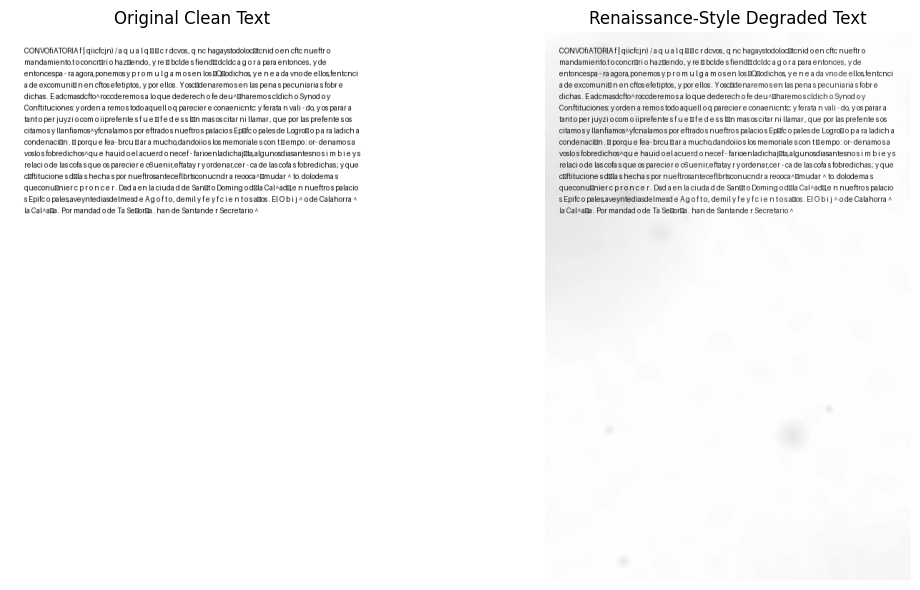

In [33]:

if __name__ == "__main__":

    class Args:
        pdf = '/content/Constituciones sinodales Calahorra 1602.pdf'
        font = "goudy_old_style.ttf"
        output = "output"
        samples = 5
        intensity = 0.6

    args = Args()

    main(
        pdf_path=args.pdf,
        font_path=args.font,
        output_dir=args.output,
        num_samples=args.samples,
        effect_intensity=args.intensity
    )